In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load data and format basic columns
df = sns.load_dataset('titanic')
df['survived_pct'] = df['survived'] * 100
df['class'] = df['class'].astype(str).str.title()
df['survived_label'] = df['survived'].map({0: 'Perished', 1: 'Survived'})

# 2. Set global presentation style
sns.set_theme(style="whitegrid", font_scale=1.3)
plt.rcParams['font.family'] = 'sans-serif'

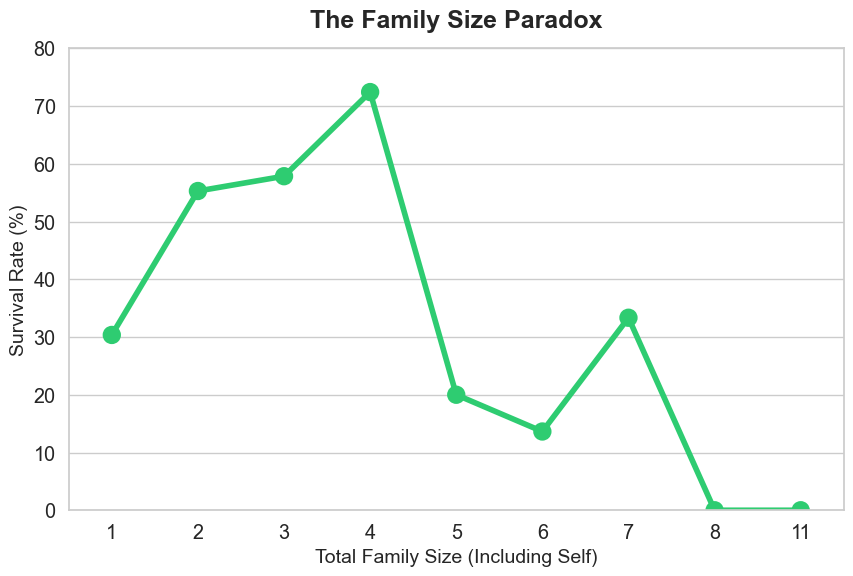

In [19]:
# Create total family size (siblings/spouses + parents/children + self)
df['family_size'] = df['sibsp'] + df['parch'] + 1

plt.figure(figsize=(10, 6), facecolor='white')
sns.pointplot(data=df, x='family_size', y='survived_pct', 
              color='#2ecc71', scale=1.5, errorbar=None)

plt.title("The Family Size Paradox", fontsize=18, fontweight='bold', pad=15)
plt.xlabel("Total Family Size (Including Self)", fontsize=14)
plt.ylabel("Survival Rate (%)", fontsize=14)
plt.ylim(0, 80)

plt.show()

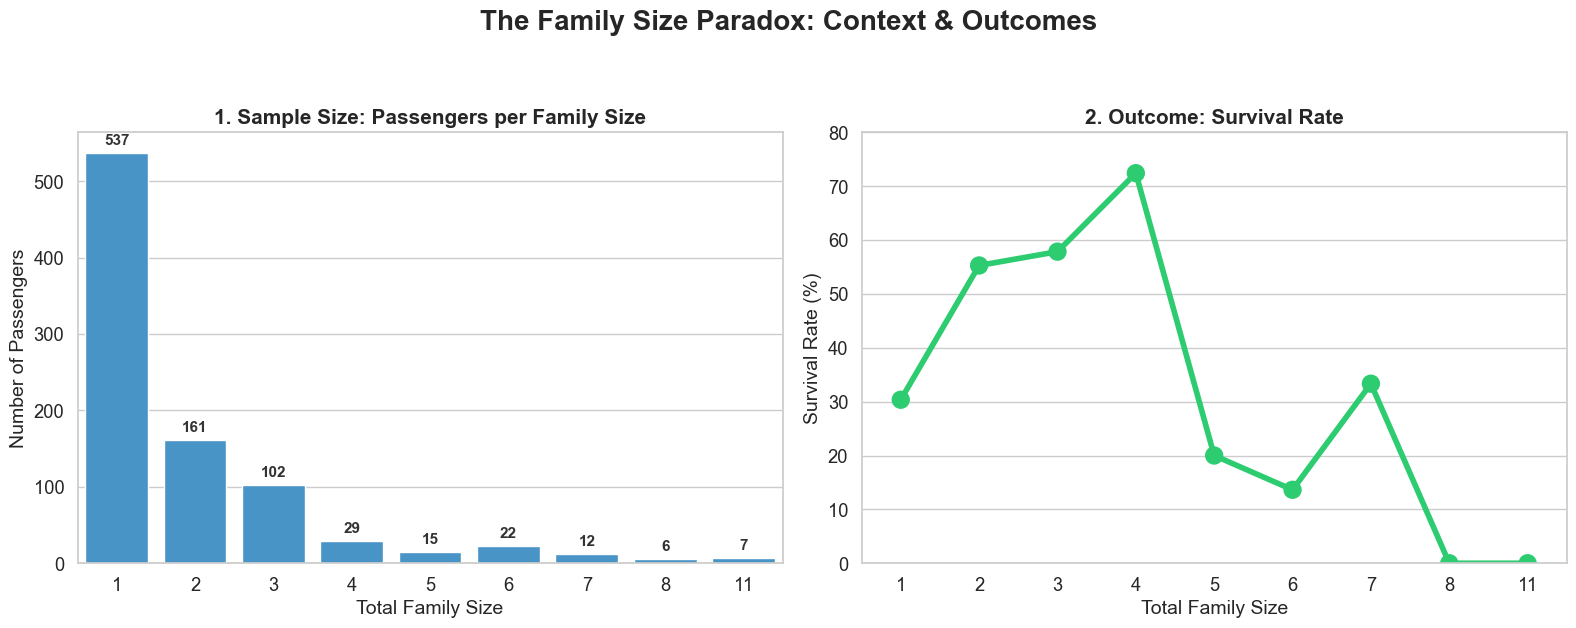

In [20]:


# 2. Set presentation style
sns.set_theme(style="whitegrid", font_scale=1.2)
plt.rcParams['font.family'] = 'sans-serif'

# 3. Create a side-by-side figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), facecolor='white')
fig.suptitle("The Family Size Paradox: Context & Outcomes", fontsize=20, fontweight='bold', y=1.05)

# ==========================================
# LEFT PLOT: Sample Size (Count)
# ==========================================
sns.countplot(data=df, x='family_size', ax=ax1, color='#3498db')
ax1.set_title("1. Sample Size: Passengers per Family Size", fontsize=15, fontweight='bold')
ax1.set_xlabel("Total Family Size", fontsize=14)
ax1.set_ylabel("Number of Passengers", fontsize=14)

# Add exact count labels on top of the bars
for p in ax1.patches:
    ax1.annotate(f"{int(p.get_height())}", 
                 (p.get_x() + p.get_width() / 2., p.get_height()), 
                 ha='center', va='bottom', fontsize=11, fontweight='bold', 
                 xytext=(0, 4), textcoords='offset points', color='#333333')

# ==========================================
# RIGHT PLOT: Survival Rate
# ==========================================
sns.pointplot(data=df, x='family_size', y='survived_pct', ax=ax2, 
              color='#2ecc71', scale=1.5, errorbar=None)
ax2.set_title("2. Outcome: Survival Rate", fontsize=15, fontweight='bold')
ax2.set_xlabel("Total Family Size", fontsize=14)
ax2.set_ylabel("Survival Rate (%)", fontsize=14)
ax2.set_ylim(0, 80)

# 4. Save and clean up
plt.tight_layout()
plt.show()

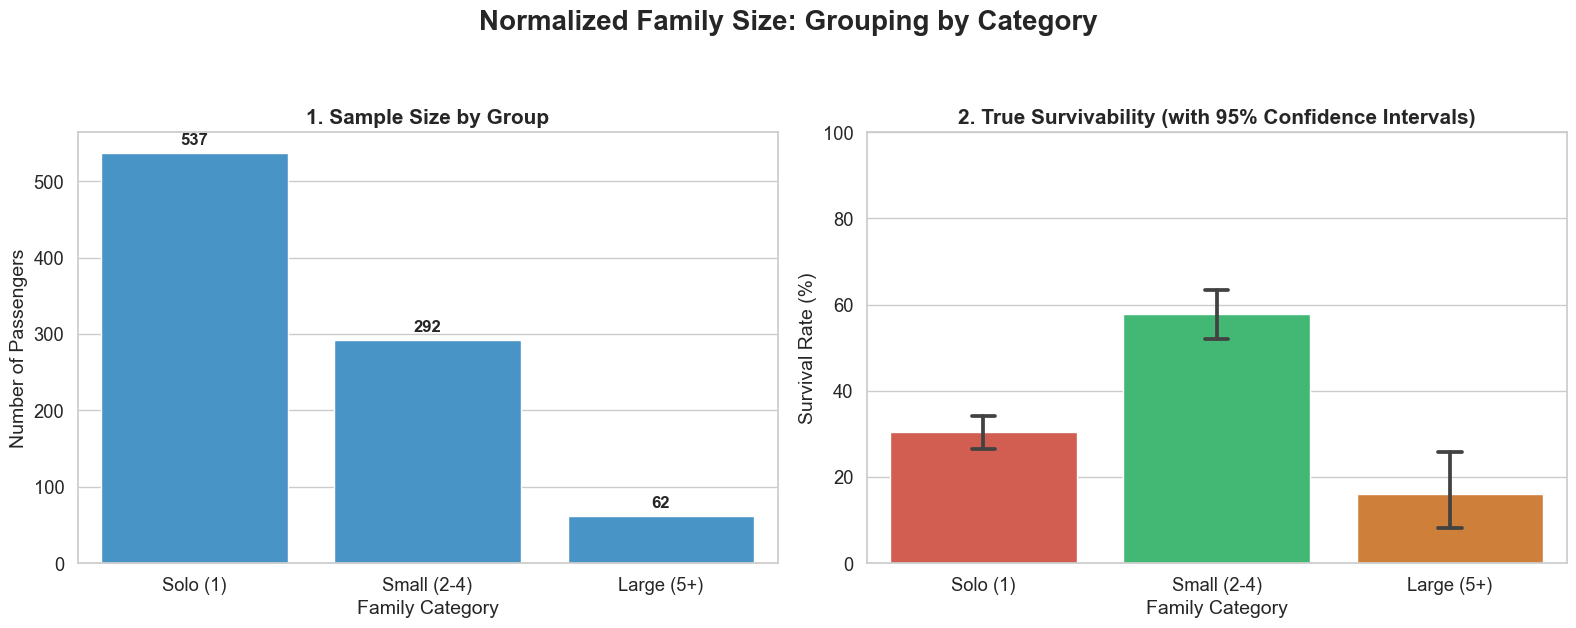

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load data and calculate raw family size
df = sns.load_dataset('titanic')
df['survived_pct'] = df['survived'] * 100
df['family_size'] = df['sibsp'] + df['parch'] + 1

# 2. Normalize the data by binning into logical groups
df['family_group'] = df['family_size'].apply(
    lambda x: 'Solo (1)' if x == 1 else ('Small (2-4)' if x <= 4 else 'Large (5+)')
)

# 3. Set presentation style
sns.set_theme(style="whitegrid", font_scale=1.2)
plt.rcParams['font.family'] = 'sans-serif'

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), facecolor='white')
fig.suptitle("Normalized Family Size: Grouping by Category", fontsize=20, fontweight='bold', y=1.05)

# ==========================================
# LEFT PLOT: Sample Size by Group
# ==========================================
sns.countplot(data=df, x='family_group', ax=ax1, color='#3498db', 
              order=['Solo (1)', 'Small (2-4)', 'Large (5+)'])
ax1.set_title("1. Sample Size by Group", fontsize=15, fontweight='bold')
ax1.set_xlabel("Family Category", fontsize=14)
ax1.set_ylabel("Number of Passengers", fontsize=14)

# Add exact count labels
for p in ax1.patches:
    ax1.annotate(f"{int(p.get_height())}", 
                 (p.get_x() + p.get_width() / 2., p.get_height()), 
                 ha='center', va='bottom', fontsize=12, fontweight='bold', 
                 xytext=(0, 4), textcoords='offset points')

# ==========================================
# RIGHT PLOT: Survival Rate with Error Bars
# ==========================================
# Note: errorbar=('ci', 95) adds the 95% confidence interval line
sns.barplot(data=df, x='family_group', y='survived_pct', ax=ax2, 
            palette=['#e74c3c', '#2ecc71', '#e67e22'], 
            order=['Solo (1)', 'Small (2-4)', 'Large (5+)'],
            capsize=0.1, errorbar=('ci', 95))

ax2.set_title("2. True Survivability (with 95% Confidence Intervals)", fontsize=15, fontweight='bold')
ax2.set_xlabel("Family Category", fontsize=14)
ax2.set_ylabel("Survival Rate (%)", fontsize=14)
ax2.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('family_size_normalized.png', dpi=300, bbox_inches='tight')
plt.show()

In [24]:
plt.figure(figsize=(12, 7), facecolor='white')

# Plot Fare vs. Class, split by Survival
sns.boxplot(data=df, x='class', y='fare', hue='survived_label', 
            palette=['#e74c3c', '#3498db'], order=['First', 'Second', 'Third'])

plt.title("Did Fare Predict Survival Within the Same Class?", fontsize=18, fontweight='bold', pad=15)
plt.xlabel("Passenger Class", fontsize=14)
plt.ylabel("Ticket Fare (£)", fontsize=14)

# Zoom in to ignore extreme outliers (like the £512 ticket) for better readability
plt.ylim(-5, 150)
plt.legend(title="Outcome", loc='upper right')

plt.savefig('slide2_hidden_wealth.png', dpi=300, bbox_inches='tight')
plt.close()

In [28]:
plt.figure(figsize=(12, 7), facecolor='white')

# FIX: Removed ax=ax2
sns.barplot(data=df, x='class', y='survived_pct', errorbar=None, order=['First', 'Second', 'Third'])

plt.title("Socioeconomic Status", fontsize=18, fontweight='bold', pad=15)
plt.xlabel("Passenger Class", fontsize=14)
plt.ylabel("Survival Rate (%)", fontsize=14)

plt.savefig("class_to_survivability.png", dpi=300, bbox_inches='tight')
plt.close()

ValueError: Could not interpret input 'age_group'

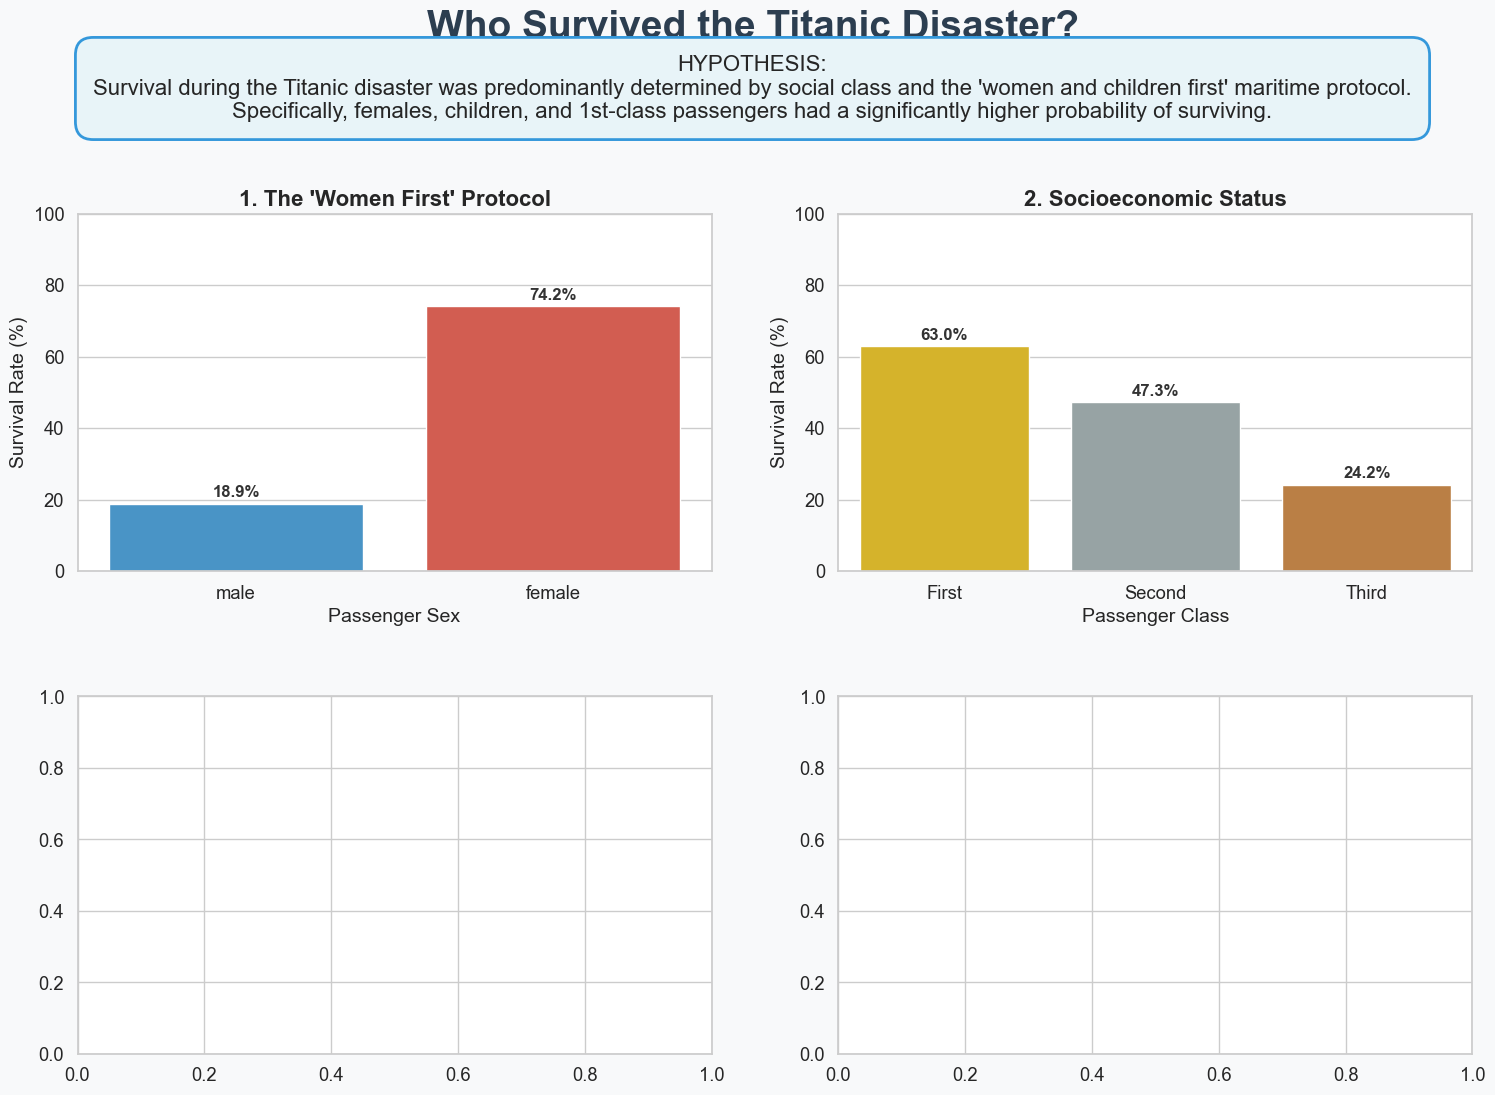

In [25]:
sns.set_theme(style="whitegrid", font_scale=1.2)
plt.rcParams['font.family'] = 'sans-serif' 
bg_color = '#f8f9fa'

palette_sex = ["#3498db", "#e74c3c"]
palette_class = ["#f1c40f", "#95a5a6", "#cd7f32"]
palette_age = ["#2ecc71", "#34495e"]

fig = plt.figure(figsize=(18, 12), facecolor=bg_color)
fig.suptitle("Who Survived the Titanic Disaster?", fontsize=28, fontweight='bold', y=0.95, color='#2c3e50')

hypothesis_text = (
    "HYPOTHESIS:\n"
    "Survival during the Titanic disaster was predominantly determined by social class and the "
    "'women and children first' maritime protocol.\n"
    "Specifically, females, children, and 1st-class passengers had a significantly higher probability of surviving."
)
fig.text(0.5, 0.86, hypothesis_text, ha='center', fontsize=16, 
         bbox=dict(boxstyle="round,pad=0.8", facecolor='#e8f4f8', edgecolor='#3498db', linewidth=2))

def add_bar_labels(ax):
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.1f}%", 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', fontsize=12, fontweight='bold', color='#333333', 
                    xytext=(0, 8), textcoords='offset points')

gs = fig.add_gridspec(2, 2, top=0.78, bottom=0.08, hspace=0.35, wspace=0.2)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

sns.barplot(data=df, x='sex', y='survived_pct', ax=ax1, palette=palette_sex, errorbar=None, order=['male', 'female'])
ax1.set_title("1. The 'Women First' Protocol", fontsize=16, fontweight='bold')
ax1.set_xlabel("Passenger Sex", fontsize=14)
ax1.set_ylabel("Survival Rate (%)", fontsize=14)
ax1.set_ylim(0, 100)
add_bar_labels(ax1)

sns.barplot(data=df, x='class', y='survived_pct', ax=ax2, palette=palette_class, errorbar=None, order=['First', 'Second', 'Third'])
ax2.set_title("2. Socioeconomic Status", fontsize=16, fontweight='bold')
ax2.set_xlabel("Passenger Class", fontsize=14)
ax2.set_ylabel("Survival Rate (%)", fontsize=14)
ax2.set_ylim(0, 100)
add_bar_labels(ax2)

sns.barplot(data=df, x='age_group', y='survived_pct', ax=ax3, palette=palette_age, errorbar=None)
ax3.set_title("3. The 'Children First' Protocol", fontsize=16, fontweight='bold')
ax3.set_xlabel("Age Group", fontsize=14)
ax3.set_ylabel("Survival Rate (%)", fontsize=14)
ax3.set_ylim(0, 100)
add_bar_labels(ax3)

sns.pointplot(data=df, x='class', y='survived_pct', hue='sex', ax=ax4, 
              palette=palette_sex, dodge=True, markers=["o", "s"], errorbar=None, order=['First', 'Second', 'Third'])
ax4.set_title("4. Intersection: Class & Sex", fontsize=16, fontweight='bold')
ax4.set_xlabel("Passenger Class", fontsize=14)
ax4.set_ylabel("Survival Rate (%)", fontsize=14)
ax4.set_ylim(0, 100)
ax4.legend(title="Sex", title_fontsize='13', fontsize='12')

footer_text = (
    "Conclusion: The pointplot (Chart 4) proves both factors acted simultaneously. While sex was the ultimate deciding factor "
    "(3rd-class females out-survived 1st-class males), within each sex, class heavily dictated your final fate."
)
fig.text(0.5, 0.02, footer_text, ha='center', fontsize=13, fontstyle='italic', color='#555555')

plt.show()

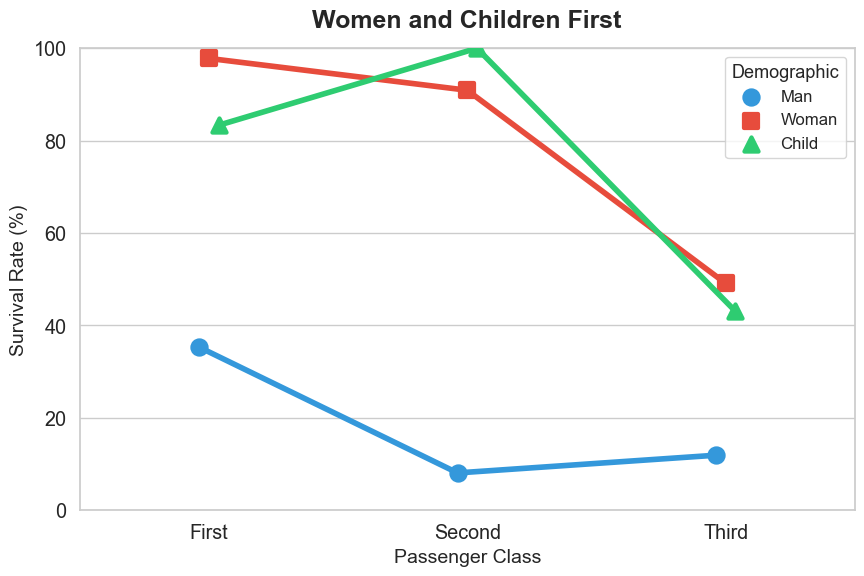

In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load and format data
df = sns.load_dataset('titanic')
df['survived_pct'] = df['survived'] * 100
df['class'] = df['class'].astype(str).str.title()

# 1. Create a new column grouping passengers by Man, Woman, or Child
df['demographic'] = df['sex'].map({'male': 'Man', 'female': 'Woman'})
df.loc[df['age'] < 16, 'demographic'] = 'Child'

# Plot styling
sns.set_theme(style="whitegrid", font_scale=1.3)
plt.figure(figsize=(10, 6), facecolor='white')

# 2. Generate the pointplot using the new 'demographic' column
sns.pointplot(data=df, x='class', y='survived_pct', hue='demographic', 
              hue_order=['Man', 'Woman', 'Child'],  # Forces a logical legend order
              palette=["#3498db", "#e74c3c", "#2ecc71"], # Added green for children
              dodge=True, markers=["o", "s", "^"], # Added triangle marker for children
              scale=1.5, errorbar=None, 
              order=['First', 'Second', 'Third'])

plt.title("Women and Children First", fontsize=18, fontweight='bold', pad=15)
plt.xlabel("Passenger Class", fontsize=14)
plt.ylabel("Survival Rate (%)", fontsize=14)
plt.ylim(0, 100)

# 3. Simplify the legend (Seaborn handles the labels automatically now)
plt.legend(title="Demographic", title_fontsize='13', fontsize='12')

plt.savefig('final_slide_intersection.png', dpi=300, bbox_inches='tight')
plt.show()